In [1]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
import numpy as np
import matplotlib.pyplot as plt

Набор данных https://www.kaggle.com/datasets/bhaveshmittal/multi-class-rice-image-dataset?resource=download представляет собой набор изображений зерен риса, включающий пять различных сортов риса. В оригинальном датасете каждый класс содержит 10000 изображений, чтобы сократить время обучения модели было решено уменьшить объем выборки до 1500 изображений на класс для обучающей выборки и 750 для тестовой

# Загрузка данных

разархивируем файл с данными

In [3]:
!unzip dataset.zip

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: dataset/Train/Karacadag/1228.jpg  
  inflating: dataset/Train/Karacadag/1229.jpg  
  inflating: dataset/Train/Karacadag/123.jpg  
  inflating: dataset/Train/Karacadag/1230.jpg  
  inflating: dataset/Train/Karacadag/1231.jpg  
  inflating: dataset/Train/Karacadag/1232.jpg  
  inflating: dataset/Train/Karacadag/1233.jpg  
  inflating: dataset/Train/Karacadag/1234.jpg  
  inflating: dataset/Train/Karacadag/1235.jpg  
  inflating: dataset/Train/Karacadag/1236.jpg  
  inflating: dataset/Train/Karacadag/1237.jpg  
  inflating: dataset/Train/Karacadag/1238.jpg  
  inflating: dataset/Train/Karacadag/1239.jpg  
  inflating: dataset/Train/Karacadag/124.jpg  
  inflating: dataset/Train/Karacadag/1240.jpg  
  inflating: dataset/Train/Karacadag/1241.jpg  
  inflating: dataset/Train/Karacadag/1242.jpg  
  inflating: dataset/Train/Karacadag/1243.jpg  
  inflating: dataset/Train/Karacadag/1244.jpg  
  inflating: dataset/T

In [2]:
base_dir = "dataset"
train_dir = os.path.join(base_dir, 'Train')
validation_dir = os.path.join(base_dir, 'Validation')

classes = [ "Arborio", "Basmati", "Ipsala", "Jasmine", "Karacadag" ]

## Обзор данных

In [3]:
total_train = 0
total_val = 0

print("Обучающая выборка:")
for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    num_images = len([name for name in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, name))])
    total_train += num_images
    print(f"{class_name}: {num_images}")
print(f"Всего изображений: {total_train}")

print("\nТестовая выборка:")
for class_name in classes:
    class_path = os.path.join(validation_dir, class_name)
    num_images = len([name for name in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, name))])
    total_val += num_images
    print(f"{class_name}: {num_images}")
print(f"Всего изображений: {total_val}")

Обучающая выборка:
Arborio: 1500
Basmati: 1500
Ipsala: 1500
Jasmine: 1500
Karacadag: 1500
Всего изображений: 7500

Тестовая выборка:
Arborio: 750
Basmati: 750
Ipsala: 750
Jasmine: 750
Karacadag: 750
Всего изображений: 3750


### Установка параметров модели

In [ ]:
BATCH_SIZE = 100
IMG_SIZE = 150

## Создангие переменных, содержащих тренировочный и валидационный наборы изображений

In [ ]:
train_image_generator = ImageDataGenerator(rescale=1./255)
validation_image_generator = ImageDataGenerator(rescale=1./255)

train_data_gen = train_image_generator.flow_from_directory(batch_size=BATCH_SIZE,
                                                          directory=train_dir,
                                                          shuffle=True,
                                                          target_size=(IMG_SIZE, IMG_SIZE),
                                                          class_mode='categorical',
                                                          classes=classes)

val_data_gen = validation_image_generator.flow_from_directory(batch_size=BATCH_SIZE,
                                                              directory=validation_dir,
                                                              shuffle=False,
                                                              target_size=(IMG_SIZE, IMG_SIZE),
                                                              class_mode='categorical',
                                                              classes=classes)

Found 7500 images belonging to 5 classes.
Found 3750 images belonging to 5 classes.


#### Визуализация изображения из тестового набора

In [ ]:
sample_training_images, _ = next(train_data_gen)

In [ ]:
def plotImages(images_arr):
  fig, axes = plt.subplots(1, 5, figsize=(20, 20))
  axes = axes.flatten()
  for img, ax in zip(images_arr, axes):
    ax.imshow(img)
  plt.tight_layout()
  plt.show()

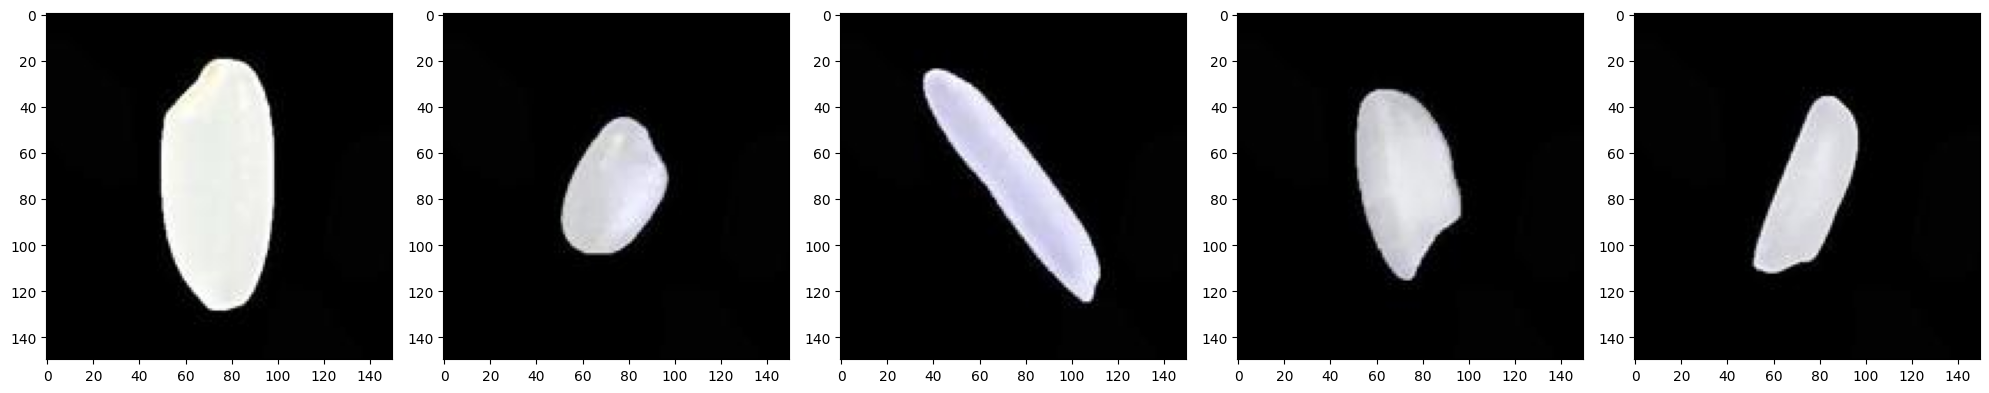

In [ ]:
plotImages(sample_training_images[0:5])

## Конструирование нейронной сети

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(classes), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Компилирование модели

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

#### Представление модели

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,173 (13.18 MB)

 Trainable params: 3,455,173 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

#### Тренировка модели

In [ ]:
EPOCHS = 10
history = model.fit(
    train_data_gen,
    steps_per_epoch=int(np.ceil(total_train / float(BATCH_SIZE))),
    epochs=EPOCHS,
    validation_data=val_data_gen,
    validation_steps=int(np.ceil(total_val / float(BATCH_SIZE)))
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 472s 6s/step - accuracy: 0.8944 - loss: 0.1401 - val_accuracy: 0.9581 - val_loss: 0.0751
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 506s 6s/step - accuracy: 0.9475 - loss: 0.0706 - val_accuracy: 0.9680 - val_loss: 0.0473
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 476s 6s/step - accuracy: 0.9589 - loss: 0.0527 - val_accuracy: 0.9696 - val_loss: 0.0390
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 500s 6s/step - accuracy: 0.9615 - loss: 0.0455 - val_accuracy: 0.9709 - val_loss: 0.0395
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 463s 6s/step - accuracy: 0.9654 - loss: 0.0457 - val_accuracy: 0.9701 - val_loss: 0.0440
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 471s 6s/step - accuracy: 0.9742 - loss: 0.0324 - val_accuracy: 0.9736 - val_loss: 0.0314
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 474s 6s/step - accuracy: 0.9788 - loss: 0.0228 - val_accuracy: 0.9829 - val_loss: 0.0226
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 526s 7s/step - accuracy: 0.9810 - loss: 0.0245 - val_accuracy: 0.9816 - v

#### Визуализация результатов тренировки

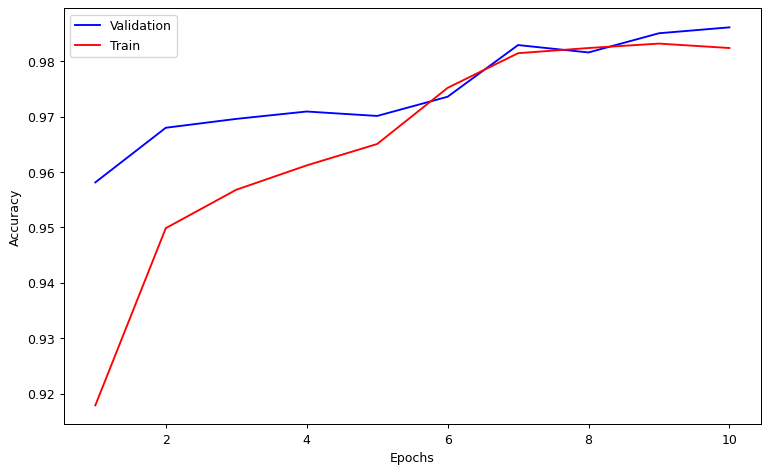

In [ ]:
history_dict = history.history
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)
plt.figure(figsize=(10,6), dpi=90)
plt.plot(epochs, val_acc_values, 'b', label='Validation')
plt.plot(epochs, acc_values, 'r', label='Train')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Наибольшую точность модель показала на 10 эпохе. Максимальная точность на тестовой выборке = 98.61%

# 2. Аугментация датасетов с картинками

In [11]:
def plotImages(images_arr):
  fig, axes = plt.subplots(1, 5, figsize=(20,20))
  axes = axes.flatten()
  for img, ax in zip(images_arr, axes):
    ax.imshow(img)
  plt.tight_layout()
  plt.show()

In [12]:
image_gen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data_gen = image_gen_train.flow_from_directory(batch_size=BATCH_SIZE,
                                                          directory=train_dir,
                                                          shuffle=True,
                                                          target_size=(IMG_SIZE, IMG_SIZE),
                                                          class_mode='categorical',
                                                          classes=classes)

Found 7500 images belonging to 5 classes.


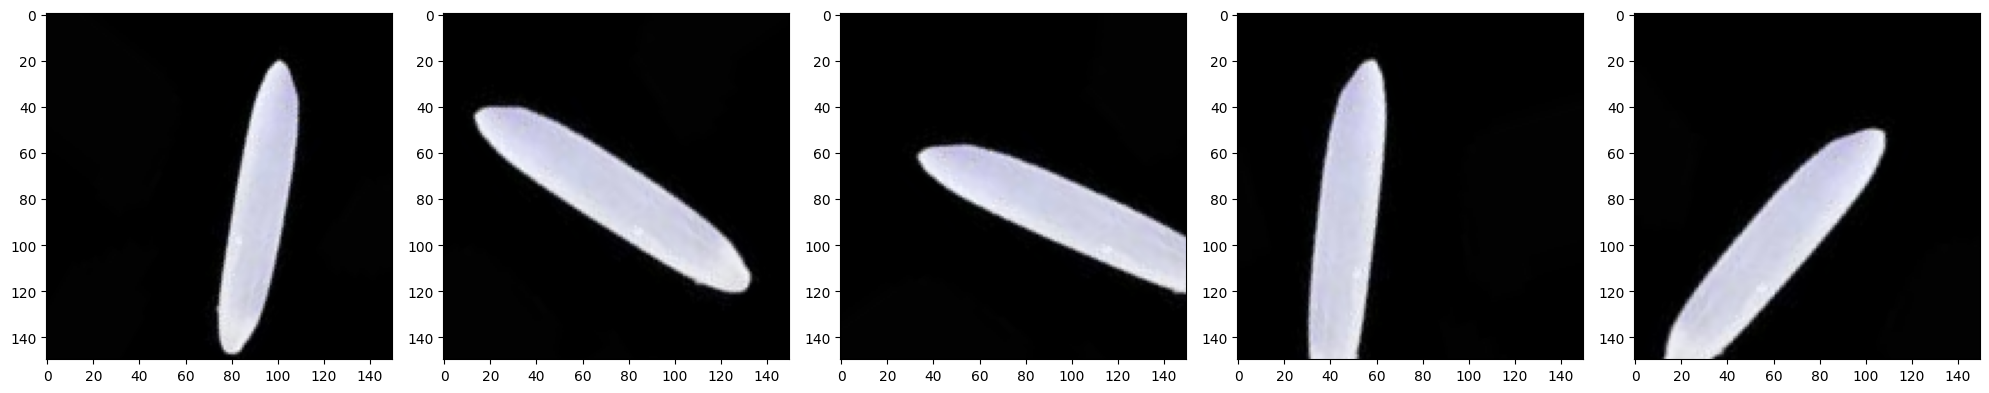

In [13]:
augmented_images = [train_data_gen[0][0][0] for i in range(5)]
plotImages(augmented_images)

#### Создаём валидационный набор данных

In [10]:
validation_image_generator = ImageDataGenerator(rescale=1./255)

val_data_gen = validation_image_generator.flow_from_directory(batch_size=BATCH_SIZE,
                                                              directory=validation_dir,
                                                              shuffle=False,
                                                              target_size=(IMG_SIZE, IMG_SIZE),
                                                              class_mode='categorical',
                                                              classes=classes)

Found 3750 images belonging to 5 classes.


## Создание модели

In [11]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(classes), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Компилирование модели

In [12]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

#### Структура модели

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,173 (13.18 MB)

 Trainable params: 3,455,173 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

#### Тренировка модели

In [14]:
EPOCHS = 10
history = model.fit(
    train_data_gen,
    steps_per_epoch=int(np.ceil(total_train / float(BATCH_SIZE))),
    epochs=EPOCHS,
    validation_data=val_data_gen,
    validation_steps=int(np.ceil(total_val / float(BATCH_SIZE)))
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 496s 7s/step - accuracy: 0.3050 - loss: 0.4891 - val_accuracy: 0.7541 - val_loss: 0.3190
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 493s 7s/step - accuracy: 0.6211 - loss: 0.3129 - val_accuracy: 0.8976 - val_loss: 0.1773
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 493s 7s/step - accuracy: 0.7588 - loss: 0.2280 - val_accuracy: 0.9493 - val_loss: 0.1381
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 492s 7s/step - accuracy: 0.8411 - loss: 0.1632 - val_accuracy: 0.9245 - val_loss: 0.1077
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 493s 7s/step - accuracy: 0.9110 - loss: 0.1068 - val_accuracy: 0.9533 - val_loss: 0.0791
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 497s 7s/step - accuracy: 0.9431 - loss: 0.0705 - val_accuracy: 0.9317 - val_loss: 0.0781
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 519s 7s/step - accuracy: 0.9382 - loss: 0.0760 - val_accuracy: 0.9597 - val_loss: 0.0770
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 490s 7s/step - accuracy: 0.9398 - loss: 0.0749 - val_accuracy: 0.9635 - v

#### Визуализация результатов тренировки

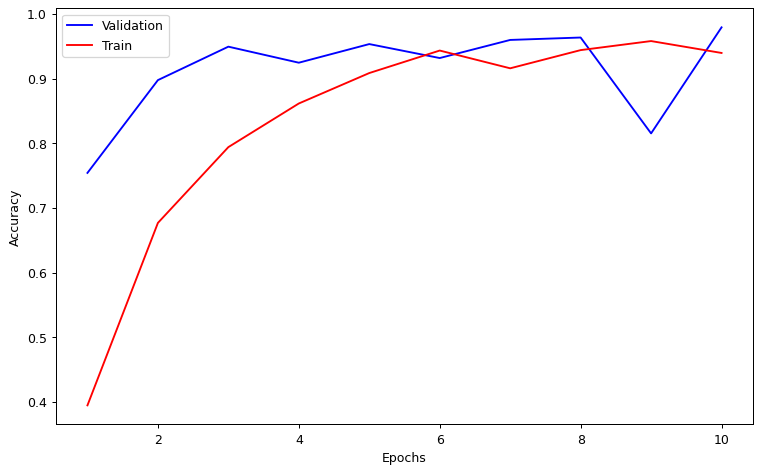

In [15]:
history_dict = history.history
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)
plt.figure(figsize=(10,6), dpi=90)
plt.plot(epochs, val_acc_values, 'b', label='Validation')
plt.plot(epochs, acc_values, 'r', label='Train')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Наибольшую точность модель показала на 10 эпохе. Максимальная точность на тестовой выборке = 97.92%. Точность модели немного упала

# 3. Перенос обучения (Transfer Learning)

In [5]:
from tensorflow.keras.applications import VGG16
vgg16_net = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 40s 1us/step


In [6]:
vgg16_net.trainable = False
vgg16_net.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## Создаем составную нейронную сеть на основе VGG16

In [14]:
model = Sequential()

model.add(vgg16_net)

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(classes), activation='softmax'))

Компиляция модели

In [15]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Структура модели

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,912,069 (72.14 MB)

 Trainable params: 4,197,381 (16.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

#### Тренировка модели

In [16]:
EPOCHS = 10
history = model.fit(
    train_data_gen,
    steps_per_epoch=int(np.ceil(total_train / float(BATCH_SIZE))),
    epochs=EPOCHS,
    validation_data=val_data_gen,
    validation_steps=int(np.ceil(total_val / float(BATCH_SIZE)))
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 534s 7s/step - accuracy: 0.7655 - loss: 0.2569 - val_accuracy: 0.9651 - val_loss: 0.0658
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 515s 7s/step - accuracy: 0.9028 - loss: 0.1188 - val_accuracy: 0.9800 - val_loss: 0.0367
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 577s 8s/step - accuracy: 0.9275 - loss: 0.0899 - val_accuracy: 0.9845 - val_loss: 0.0283
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 847s 11s/step - accuracy: 0.9336 - loss: 0.0823 - val_accuracy: 0.9819 - val_loss: 0.0307
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 511s 7s/step - accuracy: 0.9409 - loss: 0.0699 - val_accuracy: 0.9867 - val_loss: 0.0216
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 486s 7s/step - accuracy: 0.9468 - loss: 0.0662 - val_accuracy: 0.9864 - val_loss: 0.0201
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 468s 6s/step - accuracy: 0.9476 - loss: 0.0636 - val_accuracy: 0.9840 - val_loss: 0.0236
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 469s 6s/step - accuracy: 0.9524 - loss: 0.0582 - val_accuracy: 0.9845 - 

#### Визуализация результатов тренировки

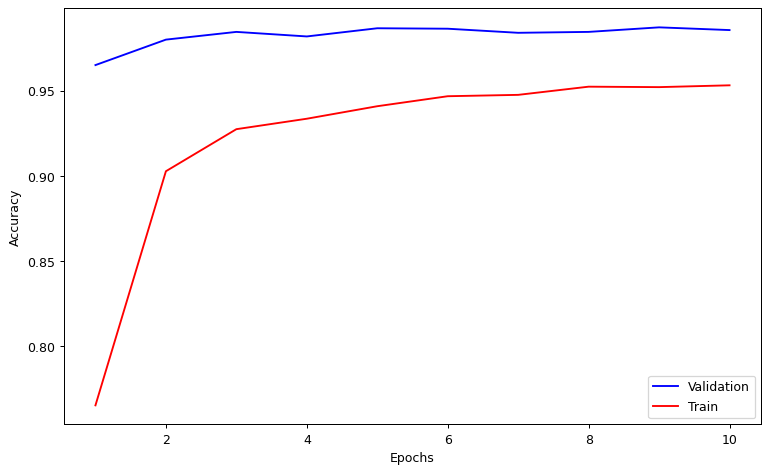

In [17]:
history_dict = history.history
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)
plt.figure(figsize=(10,6), dpi=90)
plt.plot(epochs, val_acc_values, 'b', label='Validation')
plt.plot(epochs, acc_values, 'r', label='Train')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Наибольшую точность модель показала на 9 эпохе. Максимальная точность на тестовой выборке = 98.72%. Точность модели получилась самой высокой среди обученных моделей